# Week 4

## Lecture 7 - Implementing Backpropagation

Below, we implement a fully-connected feedforward neural network with random weight initialization, customizable architecture, and gradient descent with use of backpropagation for computing the gradients. We will then test it on some examples.

The best way to understand how this all works is to actually implement it with minimal external libraries. One exception is `NumPy`, which at least automates some of the basic mathematical operations we need to do.

In [1]:
import numpy as np

Next, we will implement the feedforward neural network. The code is partly based on an implementation from *Deep Learning for Computer Vision with Python* by Adrian Rosebrock.

In [2]:
class FeedforwardNeuralNetwork:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1):
        
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in np.arange(0,epochs):

            # feed forward, backprop, and weight update
            for (x, target) in zip(X, y):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in np.arange(0, len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation
                error = A[-1] - target
                
                # term proportional to the gradient
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update
                for layer in np.arange(0, len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print a status update
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, 'loss = ', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
         
        # return the predictions
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # compute the sum of squared errors loss function
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

Let's check the variables of the model.

In [3]:
model = FeedforwardNeuralNetwork([2, 2, 1])
vars(model)

{'W': [array([[ 0.63132871, -0.08080205, -0.69662128],
         [ 0.75107371,  0.40683539, -1.52262098],
         [ 0.47355029,  0.20520432, -0.416561  ]]),
  array([[-0.28248023],
         [-1.35287043],
         [-0.24829971]])],
 'layers': [2, 2, 1],
 'alpha': 0.1}

### Example: XOR function

Let's run the code to try to learn the exclusive 'or' function, i.e. XOR.

In [4]:
import random

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

model.fit(X,y,50000,1000)

Epoch = 1000 loss =  0.4619106611018523
Epoch = 2000 loss =  0.36106735051666605
Epoch = 3000 loss =  0.13637278916400225
Epoch = 4000 loss =  0.03570030298280174
Epoch = 5000 loss =  0.016901317989218227
Epoch = 6000 loss =  0.010486935676753274
Epoch = 7000 loss =  0.007432784996172568
Epoch = 8000 loss =  0.00568966851045029
Epoch = 9000 loss =  0.004577119042406364
Epoch = 10000 loss =  0.003811415652561486
Epoch = 11000 loss =  0.0032551146689609525
Epoch = 12000 loss =  0.002834172916662236
Epoch = 13000 loss =  0.0025054165002561754
Epoch = 14000 loss =  0.0022420804086723833
Epoch = 15000 loss =  0.0020267416571867476
Epoch = 16000 loss =  0.001847597639425568
Epoch = 17000 loss =  0.0016963839163141531
Epoch = 18000 loss =  0.0015671494905090497
Epoch = 19000 loss =  0.001455505495828458
Epoch = 20000 loss =  0.0013581474719198219
Epoch = 21000 loss =  0.0012725420485956655
Epoch = 22000 loss =  0.001196715835409024
Epoch = 23000 loss =  0.0011291097579477361
Epoch = 24000 los

In [5]:
model.predict(X)

array([[0.01126963],
       [0.98487956],
       [0.98483886],
       [0.0169318 ]])

Note these are very close to 0, 1, 1, 0 -- the correct classifications for the XOR function. This neural net can classify this nonlinear problem of XOR.

### Example: Tiny MNIST

In [6]:
# load some more libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import datasets
from tensorflow.keras.utils import to_categorical

2025-08-13 03:09:21.758049: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-13 03:09:22.262327: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Let's try to classify a tiny version of the MNIST data shrunk down to 8-by-8 pixel images.

In [7]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 16, 10])
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Samples: 1797, Dimension: 64
Epoch = 100 loss =  69.14988264970481
Epoch = 200 loss =  32.66489229297211
Epoch = 300 loss =  21.74199831888416
Epoch = 400 loss =  14.152519254668746
Epoch = 500 loss =  12.582704994525907
Epoch = 600 loss =  12.117240872495291
Epoch = 700 loss =  11.82099035728336
Epoch = 800 loss =  11.582716786743443
Epoch = 900 loss =  11.429015876796809
Epoch = 1000 loss =  11.276436269808787
Training set accuracy
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       0.97      0.98      0.98       140
           2       1.00      0.99      1.00       129
           3       1.00      1.00      1.00       134
           4       0.99      0.99      0.99       139
           5       0.99      0.99      0.99       137
           6       1.00      0.97      0.99       140
           7       0.98      1.00      0.99       128
           8       0.99      0.96      0.98       127
           9       0.

Let's try the same with two hidden layers.

In [8]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data/16.0

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 32, 16, 10])
model.fit(trainX, trainY, 1000, 10)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Samples: 1797, Dimension: 64
Epoch = 10 loss =  118.35856357629645
Epoch = 20 loss =  48.9644385924219
Epoch = 30 loss =  28.78697368995422
Epoch = 40 loss =  19.122104930260846
Epoch = 50 loss =  14.422033107840255
Epoch = 60 loss =  11.438919920569958
Epoch = 70 loss =  9.278658735841724
Epoch = 80 loss =  7.721197330986179
Epoch = 90 loss =  6.212405423316818
Epoch = 100 loss =  5.254274813510422
Epoch = 110 loss =  4.588499455279102
Epoch = 120 loss =  4.058400567435035
Epoch = 130 loss =  3.6436522658707284
Epoch = 140 loss =  3.274157091630052
Epoch = 150 loss =  2.929158342380446
Epoch = 160 loss =  2.669250484365085
Epoch = 170 loss =  2.474950926496306
Epoch = 180 loss =  2.32223808453939
Epoch = 190 loss =  2.197579146243915
Epoch = 200 loss =  2.0930657551227725
Epoch = 210 loss =  2.0036091783115717
Epoch = 220 loss =  1.9256316632394797
Epoch = 230 loss =  1.8563886009864596
Epoch = 240 loss =  1.793539392487118
Epoch = 250 loss =  1.7347813120617084
Epoch = 260 loss =  1.

Almost all test images were labeled correctly, 97%! But let's take a look at the ones that were labeled wrong. Most look a bit ambiguous or messy, so it's not that surprising they were not classified correctly.

93
The correct label is 9
The predicted label is 3
112
The correct label is 0
The predicted label is 4
156
The correct label is 6
The predicted label is 1
204
The correct label is 8
The predicted label is 3
219
The correct label is 8
The predicted label is 1
266
The correct label is 9
The predicted label is 3
378
The correct label is 3
The predicted label is 7
402
The correct label is 9
The predicted label is 3
429
The correct label is 9
The predicted label is 3


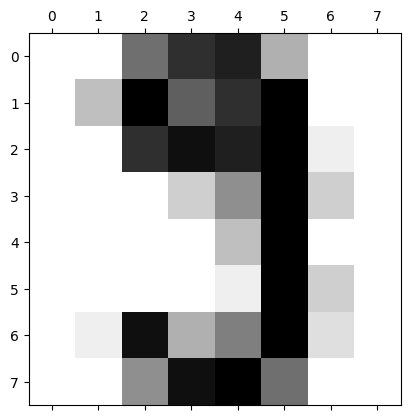

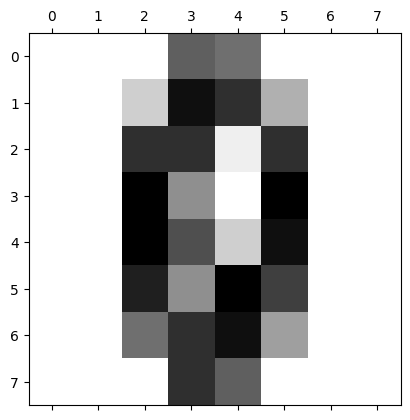

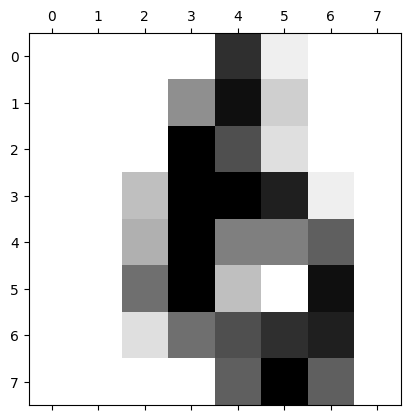

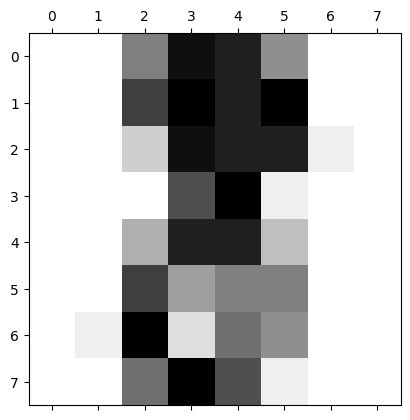

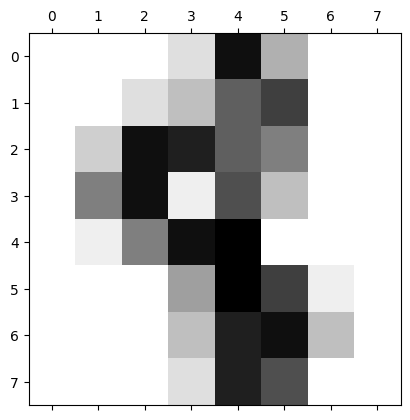

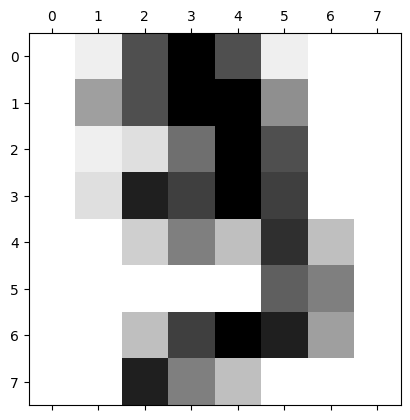

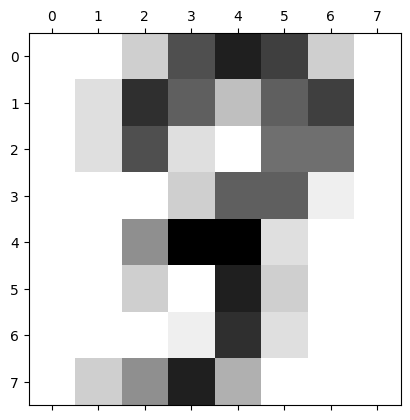

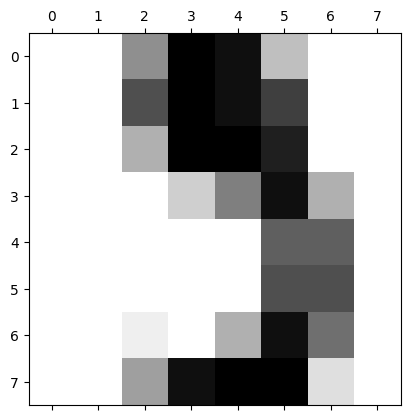

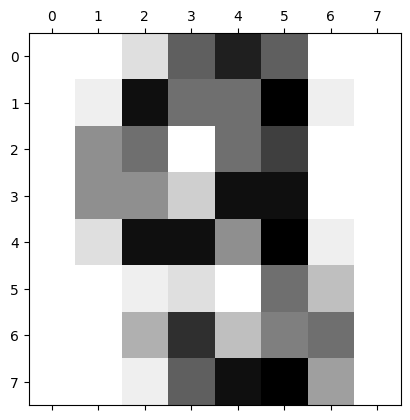

In [9]:
import matplotlib.pyplot as plt

for i in range(testX.shape[0]):
    if testY[i] != predictedY[i]:
        print(i)
        print('The correct label is', testY[i])
        print('The predicted label is', predictedY[i])
        plt.matshow(16*testX[i].reshape(8,8), cmap='gray_r')

Some of these images are really hard to interpret, even as a human, so it is unsurprising the model has trouble with them.

### Example: Full-Size MNIST

Next, let's try to use 1000 images from the full-sized MNIST dataset of 28-by-28 grayscale images.

In [10]:
from tensorflow.keras.datasets import mnist

In [11]:
### CLASSIFY MNIST PICTURES

# create a dataset of 1000 MNIST images, reshaped as single vectors, and labels
data = mnist.load_data()

# The datapoints are in mnistData[0][0]
X = data[0][0][:1000].reshape([1000,28*28])
X = X/255.0

# The labels are in mnistData[0][1]
Y = data[0][1][:1000]

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([784, 16, 10], 0.5)
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Epoch = 100 loss =  9.718121243016565
Epoch = 200 loss =  7.708984696797538
Epoch = 300 loss =  7.3187268205588
Epoch = 400 loss =  6.718198975273301
Epoch = 500 loss =  6.598647622235115
Epoch = 600 loss =  6.153691506452905
Epoch = 700 loss =  6.121417347123202
Epoch = 800 loss =  6.101965557200652
Epoch = 900 loss =  6.088338217441583
Epoch = 1000 loss =  6.078060631056525
Training set accuracy
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        77
           1       0.97      1.00      0.98        86
           2       1.00      0.99      0.99        76
           3       0.99      0.99      0.99        75
           4       0.98      0.99      0.98        80
           5       0.99      0.97      0.98        69
           6       0.97      1.00      0.99        72
           7       1.00      0.98      0.99        82
           8       1.00      0.97      0.98        61
           9       1.00      0.97      0.99        72

   

Here, we have an **overfitting** problem because the training accuracy is good, but test accuracy is significantly worse. This frequently happens when we use a small dataset. In this case, we used only 1000 images, but it still took a several minutes to run. If we used 10000 images, which would be a more ideal dataset, it would take 30-40 minutes!

This is no good... we need stochastic gradient descent to make this more useful on larger datasets.

## Lecture 8 - Speeding Up Learning (SGD, cross-entropy)

We already know what gradient descent is: we run our model on training data, compute the loss function, find the gradient of the loss function, and update our parameters in the opposite direction of the gradient by a small amount; and repeat this until the model converges. The same general approach is used in nearly all neural networks.

In linear regression and logistic classification, we were computing the outputs and loss function for the entire dataset (usually multiple times) per iteration of gradient descent, making a weight update based on the gradient, and repeating.

The typical approach used in modern neural networks is **stochastic** gradient descent (SGD). SGD updates weights after processing a random sample, called a **mini-batch**, of datapoints: enough points to reduce the variance of using just one for more stable convergence of parameters but not so much that the computation is too expensive. In this way, we process a mini-batch for outputs, compute an approximate loss function and approximate gradients, update weights, and repeat.

### How large should our mini-batches be?

Typically, using $2^n$ for something like $n=5, 6, 7, 8$ because these values tend to be ideal for the linear algebra optimization libraries we use (NumPy, TensorFlow, etc). The mini-batch size is a hyperparameter, but it generally isn't one you need to tweak too much.

One exception is if you are using GPUs for computing: then, it's typically best to choose the largest power of 2 that allows a whole mini-batch to fit into GPU memory, which will result in the underlying linear algebra libraries working optimally.

### Implementing SGD

Once we implement SGD with backpropagation, we will have constructed a "vanilla" neural network, which is probably the simplest neural network that is of practical use.

First, let's import some libraries we will be using.

In [12]:
# load some libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.datasets import mnist
from keras.utils import to_categorical

Next, we will write a class similar to the `FeedforwardNeuralNetwork` class we wrote previously but upgraded to use SGD.

In [13]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

### Example: MNIST

As promised, this SGD neural net should run faster, so let's try to use the full 60,000 training images available in MNIST and 10,000 test images. (This is still a LOT of computation, using 70000 total 28-by-28 images.

In [ ]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.5, 32)
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Epoch = 1 	 loss = 8639.687195487562
Epoch = 2 	 loss = 4071.4004486753065
Epoch = 3 	 loss = 3151.0579503346667
Epoch = 4 	 loss = 3216.2059859218557
Epoch = 5 	 loss = 3182.5649504997023
Epoch = 6 	 loss = 2764.367450937737
Epoch = 7 	 loss = 2635.7191833703178
Epoch = 8 	 loss = 2615.0787869185892


Our test accuracy on MNIST jumped from mid-80\% previously to 95\% with our implementation using SGD and the full dataset!

### Cross-Entropy Loss Function

We will discuss in class, but the cross-entropy loss function can lead to faster training than the SSE we have used before, so we add it to the implementation.

In [ ]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32, loss = 'sum-of-squares'):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # loss function
        self.loss = loss
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                if self.loss == 'sum-of-squares':
                    D = [error * self.sigmoidDerivative(A[-1])]
                    
                if self.loss == 'cross-entropy':
                    D = [error]
                    
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # if the loss function is sum of squares, compute it
        if self.loss == 'sum-of-squares':
            loss = np.sum((predictions - y)**2) / 2.0
            
        # if the loss function is cross-entropy, compute it
        if self.loss == 'cross-entropy':
            loss = np.sum(np.nan_to_num(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)))
        
        return loss

In [ ]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.1, 32, 'cross-entropy')
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

We get similar to slightly better results here.

# Week 4

## Lecture 7 - Implementing Backpropagation

Below, we implement a fully-connected feedforward neural network with random weight initialization, customizable architecture, and gradient descent with use of backpropagation for computing the gradients. We will then test it on some examples.

The best way to understand how this all works is to actually implement it with minimal external libraries. One exception is `NumPy`, which at least automates some of the basic mathematical operations we need to do.

In [ ]:
import numpy as np

Next, we will implement the feedforward neural network. The code is partly based on an implementation from *Deep Learning for Computer Vision with Python* by Adrian Rosebrock.

In [ ]:
class FeedforwardNeuralNetwork:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1):
        
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in np.arange(0,epochs):

            # feed forward, backprop, and weight update
            for (x, target) in zip(X, y):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in np.arange(0, len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation
                error = A[-1] - target
                
                # term proportional to the gradient
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update
                for layer in np.arange(0, len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print a status update
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, 'loss = ', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
         
        # return the predictions
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # compute the sum of squared errors loss function
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

Let's check the variables of the model.

In [ ]:
model = FeedforwardNeuralNetwork([2, 2, 1])
vars(model)

### Example: XOR function

Let's run the code to try to learn the exclusive 'or' function, i.e. XOR.

In [ ]:
import random

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

model.fit(X,y,50000,1000)

In [ ]:
model.predict(X)

Note these are very close to 0, 1, 1, 0 -- the correct classifications for the XOR function. This neural net can classify this nonlinear problem of XOR.

### Example: Tiny MNIST

In [ ]:
# load some more libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import datasets
from tensorflow.keras.utils import to_categorical

Let's try to classify a tiny version of the MNIST data shrunk down to 8-by-8 pixel images.

In [ ]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 16, 10])
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Let's try the same with two hidden layers.

In [ ]:
### CLASSIFY MNIST PICTURES

# 'digits' is a tiny version of MNIST in sklearn.datasets has only 8 x 8 pixels
# with grayscale values from 0 to 16
digits = datasets.load_digits()
data = digits.data.astype("float")
print("Samples: {}, Dimension: {}".format(data.shape[0], data.shape[1]))

X = data/16.0

Y = digits.target

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

# we need to turn the labels into 1-hot representations
trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([64, 32, 16, 10])
model.fit(trainX, trainY, 1000, 10)

# print the classification performance
print("Training set accuracy")

predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)

print(classification_report(trainY, predictedY))

print("Test set accuracy")

predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)

print(classification_report(testY, predictedY))

Almost all test images were labeled correctly, 97%! But let's take a look at the ones that were labeled wrong. Most look a bit ambiguous or messy, so it's not that surprising they were not classified correctly.

In [ ]:
import matplotlib.pyplot as plt

for i in range(testX.shape[0]):
    if testY[i] != predictedY[i]:
        print(i)
        print('The correct label is', testY[i])
        print('The predicted label is', predictedY[i])
        plt.matshow(16*testX[i].reshape(8,8), cmap='gray_r')

Some of these images are really hard to interpret, even as a human, so it is unsurprising the model has trouble with them.

### Example: Full-Size MNIST

Next, let's try to use 1000 images from the full-sized MNIST dataset of 28-by-28 grayscale images.

In [ ]:
from tensorflow.keras.datasets import mnist

In [ ]:
### CLASSIFY MNIST PICTURES

# create a dataset of 1000 MNIST images, reshaped as single vectors, and labels
data = mnist.load_data()

# The datapoints are in mnistData[0][0]
X = data[0][0][:1000].reshape([1000,28*28])
X = X/255.0

# The labels are in mnistData[0][1]
Y = data[0][1][:1000]

# randomly choose 75% of the data to be the training set and 25% for the testing set
trainX, testX, trainY, testY = train_test_split(X, Y, test_size = 0.25)

trainY = to_categorical(trainY)
testY = to_categorical(testY)

# fit the model to the training data
model = FeedforwardNeuralNetwork([784, 16, 10], 0.5)
model.fit(trainX, trainY, 1000, 100)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Here, we have an **overfitting** problem because the training accuracy is good, but test accuracy is significantly worse. This frequently happens when we use a small dataset. In this case, we used only 1000 images, but it still took a several minutes to run. If we used 10000 images, which would be a more ideal dataset, it would take 30-40 minutes!

This is no good... we need stochastic gradient descent to make this more useful on larger datasets.

## Lecture 8 - Speeding Up Learning (SGD, cross-entropy)

We already know what gradient descent is: we run our model on training data, compute the loss function, find the gradient of the loss function, and update our parameters in the opposite direction of the gradient by a small amount; and repeat this until the model converges. The same general approach is used in nearly all neural networks.

In linear regression and logistic classification, we were computing the outputs and loss function for the entire dataset (usually multiple times) per iteration of gradient descent, making a weight update based on the gradient, and repeating.

The typical approach used in modern neural networks is **stochastic** gradient descent (SGD). SGD updates weights after processing a random sample, called a **mini-batch**, of datapoints: enough points to reduce the variance of using just one for more stable convergence of parameters but not so much that the computation is too expensive. In this way, we process a mini-batch for outputs, compute an approximate loss function and approximate gradients, update weights, and repeat.

### How large should our mini-batches be?

Typically, using $2^n$ for something like $n=5, 6, 7, 8$ because these values tend to be ideal for the linear algebra optimization libraries we use (NumPy, TensorFlow, etc). The mini-batch size is a hyperparameter, but it generally isn't one you need to tweak too much.

One exception is if you are using GPUs for computing: then, it's typically best to choose the largest power of 2 that allows a whole mini-batch to fit into GPU memory, which will result in the underlying linear algebra libraries working optimally.

### Implementing SGD

Once we implement SGD with backpropagation, we will have constructed a "vanilla" neural network, which is probably the simplest neural network that is of practical use.

First, let's import some libraries we will be using.

In [ ]:
# load some libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.datasets import mnist
from keras.utils import to_categorical

Next, we will write a class similar to the `FeedforwardNeuralNetwork` class we wrote previously but upgraded to use SGD.

In [ ]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                D = [error * self.sigmoidDerivative(A[-1])]
                
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        loss = np.sum((predictions - y)**2) / 2.0
        
        return loss

### Example: MNIST

As promised, this SGD neural net should run faster, so let's try to use the full 60,000 training images available in MNIST and 10,000 test images. (This is still a LOT of computation, using 70000 total 28-by-28 images.

In [ ]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.5, 32)
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

Our test accuracy on MNIST jumped from mid-80\% previously to 95\% with our implementation using SGD and the full dataset!

### Cross-Entropy Loss Function

We will discuss in class, but the cross-entropy loss function can lead to faster training than the SSE we have used before, so we add it to the implementation.

In [ ]:
class FeedforwardNeuralNetworkSGD:
    
    # input a vector [a, b, c, ...] with the number of nodes in each layer
    def __init__(self, layers, alpha = 0.1, batchSize = 32, loss = 'sum-of-squares'):
        # list of weight matrices between layers
        self.W = []
        
        # network architecture will be a vector of numbers of nodes for each layer
        self.layers = layers
        
        # learning rate
        self.alpha = alpha
        
        # batch size
        self.batchSize = batchSize
        
        # loss function
        self.loss = loss
        
        # initialize the weights (randomly) -- this is our initial guess for gradient descent
        
        # initialize the weights between layers (up to the next-to-last one) as normal random variables
        for i in np.arange(0, len(layers) - 2):
            self.W.append(np.random.randn(layers[i] + 1, layers[i + 1] + 1))
            
        # initialize weights between the last two layers (we don't want bias for the last one)
        self.W.append(np.random.randn(layers[-2] + 1, layers[-1]))
        
    # define the sigmoid activation
    def sigmoid(self, x):
        return 1.0 / (1 + np.exp(-x))
    
    # define the sigmoid derivative (where z is the output of a sigmoid)
    def sigmoidDerivative(self, z):
        return z * (1 - z)
    
    # get a new mini-batch of data from the dataset
    def getNextBatch(self, X, y, batchSize):
        for i in np.arange(0, X.shape[0], batchSize):
            # yield returns a generator, which can continue where it left off on later calls
            # of the function
            yield (X[i:i + batchSize], y[i:i + batchSize])
    
    # fit the model
    def fit(self, X, y, epochs = 10000, update = 1000):
        # add a column of ones to the end of X
        X = np.hstack((X, np.ones([X.shape[0],1])))

        for epoch in range(epochs):
            
            # randomize the examples
            p = np.arange(0, X.shape[0])
            np.random.shuffle(p)
            X = X[p]
            y = y[p]

            # feed forward, backprop, and weight update
            for (x, target) in self.getNextBatch(X, y, self.batchSize):
                
                # make a list of output activations from the first layer
                # (just the original x values)
                A = [np.atleast_2d(x)]
                
                # feed forward
                for layer in range(len(self.W)):
                    
                    # feed through one layer and apply sigmoid activation
                    net = A[layer].dot(self.W[layer])
                    out = self.sigmoid(net)
                    
                    # add our network output to the list of activations
                    A.append(out)
                    
                # backpropagation (coming soon!)
                error = A[-1] - target
                
                if self.loss == 'sum-of-squares':
                    D = [error * self.sigmoidDerivative(A[-1])]
                    
                if self.loss == 'cross-entropy':
                    D = [error]
                    
                # loop backwards over the layers to build up deltas
                for layer in np.arange(len(A) - 2, 0, -1):
                    delta = D[-1].dot(self.W[layer].T)
                    delta = delta * self.sigmoidDerivative(A[layer])
                    D.append(delta)
                    
                # reverse the deltas since we looped in reverse
                D = D[::-1]
                
                # weight update in each layer
                for layer in range(len(self.W)):
                    self.W[layer] -= self.alpha * A[layer].T.dot(D[layer])
                    
            # print an 
            if (epoch + 1) % update == 0:
                loss = self.computeLoss(X,y)
                print('Epoch =', epoch + 1, '\t loss =', loss)
                
    def predict(self, X, addOnes = True):
        # initialize data, be sure it's the right dimension
        p = np.atleast_2d(X)
        
        # add a column of 1s for bias
        if addOnes:
            p = np.hstack((p, np.ones([X.shape[0],1])))
        
        # feed forward!
        for layer in np.arange(0, len(self.W)):
            p = self.sigmoid(np.dot(p, self.W[layer]))
            
        return p
    
    def computeLoss(self, X, y):
        # initialize data, be sure it's the right dimension
        y = np.atleast_2d(y)
        
        # feed the datapoints through the network to get predicted outputs
        predictions = self.predict(X, addOnes = False)
        
        # if the loss function is sum of squares, compute it
        if self.loss == 'sum-of-squares':
            loss = np.sum((predictions - y)**2) / 2.0
            
        # if the loss function is cross-entropy, compute it
        if self.loss == 'cross-entropy':
            loss = np.sum(np.nan_to_num(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)))
        
        return loss

In [ ]:
### CLASSIFY MNIST PICTURES

# load the full MNIST dataset: both data and labels
((trainX, trainY), (testX, testY)) = mnist.load_data()

# scale the data to values in [0,1]
trainX = trainX.astype('float32')/255.0
testX = testX.astype('float32')/255.0

# reshape the data
trainX = trainX.reshape([60000, 28*28])
testX = testX.reshape([10000, 28*28])

# convert the digits to one-hot vectors
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

# fit the model to the training data
model = FeedforwardNeuralNetworkSGD([784, 32, 16, 10], 0.1, 32, 'cross-entropy')
model.fit(trainX, trainY, 100, 1)

# print the classification performance
print("Training set accuracy")
predictedY = model.predict(trainX)
predictedY = predictedY.argmax(axis=1)

trainY = trainY.argmax(axis=1)
print(classification_report(trainY, predictedY))

print("Test set accuracy")
predictedY = model.predict(testX)
predictedY = predictedY.argmax(axis=1)

testY = testY.argmax(axis=1)
print(classification_report(testY, predictedY))

We get similar to slightly better results here.